In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns  
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/sofiiashmatko/labwork1/pokemon.csv
/kaggle/input/datasets/sofiiashmatko/labwork1/tests.csv
/kaggle/input/datasets/sofiiashmatko/labwork1/combats.csv


# Завантаження датасету 

In [2]:
data = pd.read_csv('/kaggle/input/datasets/sofiiashmatko/labwork1/combats.csv')
data.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [3]:
data1 = pd.read_csv('/kaggle/input/datasets/sofiiashmatko/labwork1/pokemon.csv')
data1.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [4]:
data2 = pd.read_csv('/kaggle/input/datasets/sofiiashmatko/labwork1/tests.csv')
data2.head()

,First_pokemon,Second_pokemon
0,129,117
1,660,211
2,706,115
3,195,618
4,27,656


# Візуалізація. Heatmap

In [5]:
data1.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


In [6]:
corr = data1.corr(numeric_only=True)
corr

,#,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
#,1.000000,0.097712,0.102664,0.094691,0.089199,0.085596,0.012181,0.983428,0.154336
HP,0.097712,1.000000,0.422386,0.239622,0.362380,0.378718,0.175952,0.058683,0.273620
Attack,0.102664,0.422386,1.000000,0.438687,0.396362,0.263990,0.381240,0.051451,0.345408
Defense,0.094691,0.239622,0.438687,1.000000,0.223549,0.510747,0.015227,0.042419,0.246377
Sp. Atk,0.089199,0.362380,0.396362,0.223549,1.000000,0.506121,0.473018,0.036437,0.448907
Sp. Def,0.085596,0.378718,0.263990,0.510747,0.506121,1.000000,0.259133,0.028486,0.363937
Speed,0.012181,0.175952,0.381240,0.015227,0.473018,0.259133,1.000000,-0.023121,0.326715
Generation,0.983428,0.058683,0.051451,0.042419,0.036437,0.028486,-0.023121,1.000000,0.079794
Legendary,0.154336,0.273620,0.345408,0.246377,0.448907,0.363937,0.326715,0.079794,1.000000


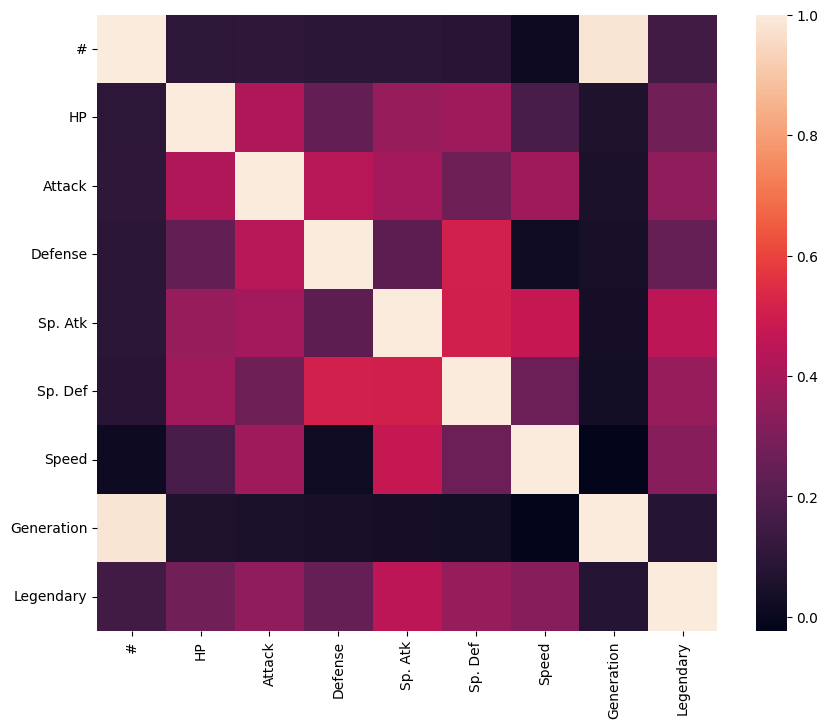

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = data1.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr)
plt.show()

# Візуалізація Barchart

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   50000 non-null  int64
 1   Second_pokemon  50000 non-null  int64
 2   Winner          50000 non-null  int64
dtypes: int64(3)
memory usage: 1.1 MB


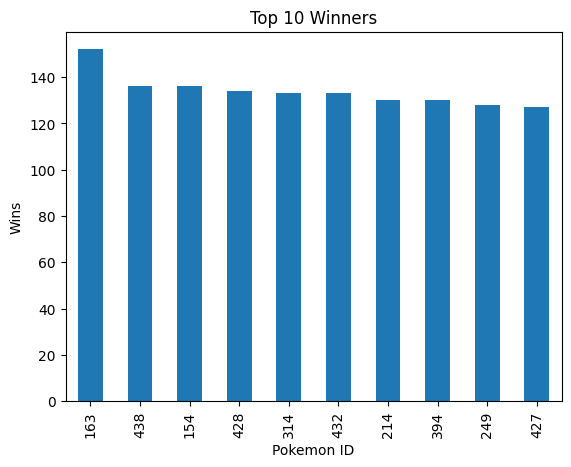

In [9]:
import matplotlib.pyplot as plt

data['Winner'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Pokemon ID')
plt.ylabel('Wins')
plt.title('Top 10 Winners')
plt.show()

# Візуалізація Histogram

In [10]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   10000 non-null  int64
 1   Second_pokemon  10000 non-null  int64
dtypes: int64(2)
memory usage: 156.4 KB


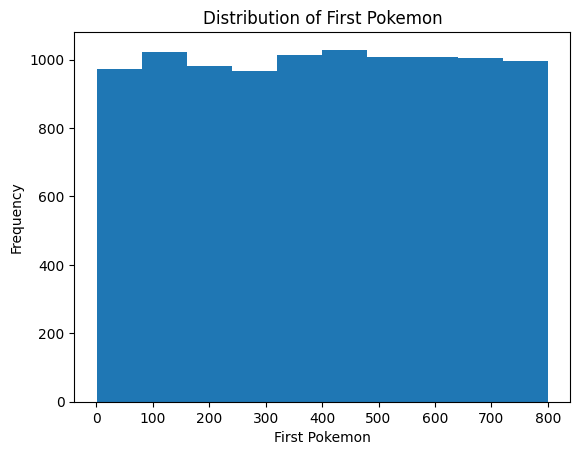

In [11]:
data2['First_pokemon'].plot(kind='hist')
plt.xlabel('First Pokemon')
plt.title('Distribution of First Pokemon')
plt.show()

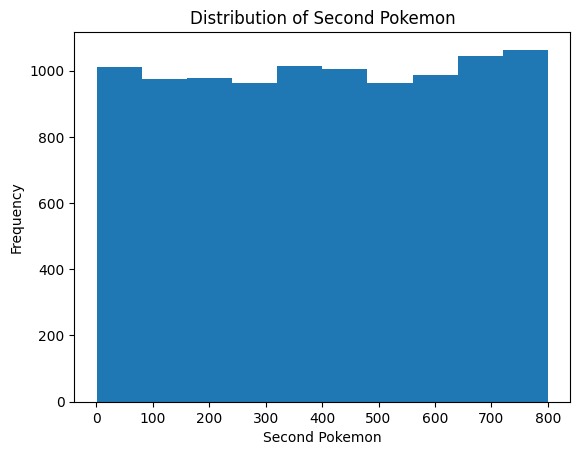

In [12]:
data2['Second_pokemon'].plot(kind='hist')
plt.xlabel('Second Pokemon')
plt.title('Distribution of Second Pokemon')
plt.show()

# Очищення даних

In [13]:
# Перевірка пропущених значень
print("Пропущені значення:")
print(data.isnull().sum())

# Перевірка дублікатів
print("\nКількість дублікатів:")
print(data.duplicated().sum())

# Видалення дублікатів
data = data.drop_duplicates()

# Перевірка типів даних
print("\nТипи даних:")
print(data.info())

# Перевірка розміру після очищення
print("\nРозмір датасету після очищення:")
print(data.shape)

Пропущені значення:
First_pokemon     0
Second_pokemon    0
Winner            0
dtype: int64

Кількість дублікатів:
1952

Типи даних:
<class 'pandas.core.frame.DataFrame'>
Index: 48048 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   48048 non-null  int64
 1   Second_pokemon  48048 non-null  int64
 2   Winner          48048 non-null  int64
dtypes: int64(3)
memory usage: 1.5 MB
None

Розмір датасету після очищення:
(48048, 3)


In [14]:
print("\nОпис числових колонок:")
display(data1.info())

print("\nКількість пропущених значень у кожній колонці:")
print(data1.isnull().sum())

if 'Type 2' in data1.columns:
    data1['Type 2'] = data1['Type 2'].fillna('Unknown')

print("\nКількість дублікатів:")
print(data1.duplicated().sum())

data1 = data1.drop_duplicates()

print("\nРозміри датасету після очищення:")
print(data1.shape)

print("\nПропуски після очищення:")
print(data1.isnull().sum())




Опис числових колонок:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


None


Кількість пропущених значень у кожній колонці:
#               0
Name            1
Type 1          0
Type 2        386
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

Кількість дублікатів:
0

Розміри датасету після очищення:
(800, 12)

Пропуски після очищення:
#             0
Name          1
Type 1        0
Type 2        0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64


In [15]:
print("Пропущені значення:")
print(data2.isnull().sum())

print("\nКількість дублікатів:")
print(data2.duplicated().sum())

data2 = data2.drop_duplicates()

print("\nТипи даних:")
print(data2.info())

print("\nРозмір датасету після очищення:")
print(data2.shape)

Пропущені значення:
First_pokemon     0
Second_pokemon    0
dtype: int64

Кількість дублікатів:
70

Типи даних:
<class 'pandas.core.frame.DataFrame'>
Index: 9930 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   9930 non-null   int64
 1   Second_pokemon  9930 non-null   int64
dtypes: int64(2)
memory usage: 232.7 KB
None

Розмір датасету після очищення:
(9930, 2)
